<a href="https://colab.research.google.com/github/gunavathibaskaran170/AI-project-/blob/main/WeatherForecastAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install snowflake-connector-python pandas scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 3.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pyopenssl to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 111.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.9 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
  Attempting uninstall: pyOpenSSL
    Found 

In [6]:
import snowflake.connector
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

conn = snowflake.connector.connect(
    user='GunavathiBaskaran',
    password='Qwertyuiopasdf1234',
    account='SCJYKFE-ES76092',
    database='WEATHER',
    schema='PUBLIC',
    warehouse='COMPUTE_WH'
)

In [7]:
query='SELECT * FROM "WEATHERFORECAST"'
df=pd.read_sql(query,conn)
conn.close()
print(df.head())

/tmp/ipykernel_1271/3325496415.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,conn)


   TEMPERATURE   HUMIDITY  WIND_SPEED  CLOUD_COVER     PRESSURE     RAIN
0    23.720338  89.592641    7.335604    50.501694  1032.378759     rain
1    27.879734  46.489704    5.952484     4.990053   992.614190  no rain
2    25.069084  83.072843    1.371992    14.855784  1007.231620  no rain
3    23.622080  74.367758    7.050551    67.255282   982.632013     rain
4    20.591370  96.858822    4.643921    47.676444   980.825142  no rain


In [8]:
df.isnull().sum()

,0
TEMPERATURE,0
HUMIDITY,0
WIND_SPEED,0
CLOUD_COVER,0
PRESSURE,0
RAIN,0


In [36]:
numeric_df = df.select_dtypes(include='number')
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((numeric_df < (Q1 - 1.5 * IQR)) |
            (numeric_df > (Q3 + 1.5 * IQR)))
print(outliers.sum())

TEMPERATURE    0
HUMIDITY       0
WIND_SPEED     0
CLOUD_COVER    0
PRESSURE       0
dtype: int64


<Axes: ylabel='CLOUD_COVER'>

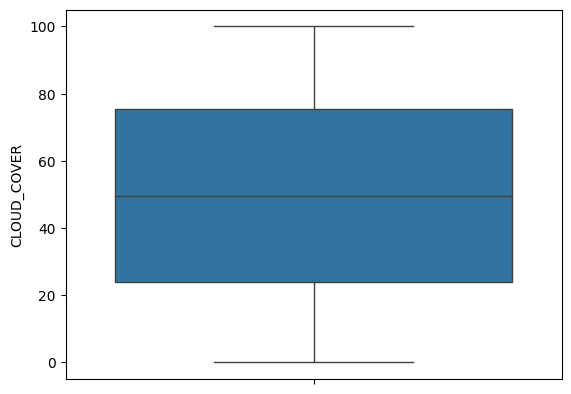

In [9]:
sns.boxplot(df['CLOUD_COVER'])

<Axes: ylabel='TEMPERATURE'>

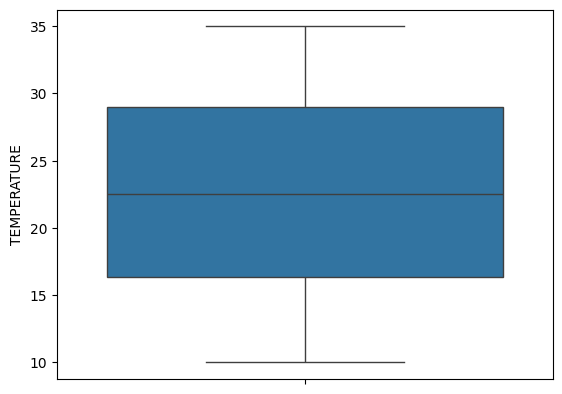

In [10]:
sns.boxplot(df['TEMPERATURE'])

<Axes: ylabel='PRESSURE'>

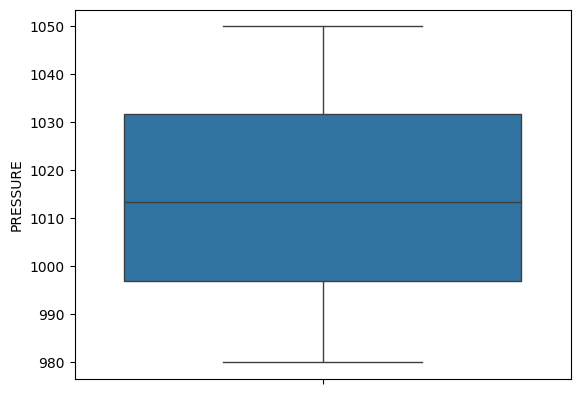

In [11]:
sns.boxplot(df['PRESSURE'])

In [12]:
X=df.iloc[:,:-1]
y=df['RAIN']


In [37]:
df.corr(numeric_only=True)

,TEMPERATURE,HUMIDITY,WIND_SPEED,CLOUD_COVER,PRESSURE
TEMPERATURE,1.000000,-0.014119,-0.004957,0.006632,-0.007489
HUMIDITY,-0.014119,1.000000,0.003816,0.007244,-0.032089
WIND_SPEED,-0.004957,0.003816,1.000000,-0.000405,0.018772
CLOUD_COVER,0.006632,0.007244,-0.000405,1.000000,0.023100
PRESSURE,-0.007489,-0.032089,0.018772,0.023100,1.000000


In [38]:
df.groupby('RAIN')[['TEMPERATURE','HUMIDITY','CLOUD_COVER']].mean()

,TEMPERATURE,HUMIDITY,CLOUD_COVER
RAIN,,,
no rain,23.319913,61.455151,46.058162
rain,17.442619,84.480176,74.720123


The dataset is very clean

*   The classes are clearly separated
*   There is no random noise

So:

👉 The model has no chance to make mistakes

👉 That’s why it is getting 100% accuracy

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)


In [30]:
from sklearn.tree import DecisionTreeClassifier
model= DecisionTreeClassifier(criterion='gini')
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [31]:
y_pred=model.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score
train_pre= model.predict(X_train)
test_pre =model.predict(X_test)

train_ac= accuracy_score(y_train,train_pre)
test_ac= accuracy_score(y_test,test_pre)
print("train accuracy:",train_ac)
print("test accuracy:",test_ac)

train accuracy: 1.0
test accuracy: 1.0


In [33]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Classification report:",classification_report(y_test,y_pred))

Accuracy: 1.0
Classification report:               precision    recall  f1-score   support

     no rain       1.00      1.00      1.00       443
        rain       1.00      1.00      1.00        57

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500

